# Hill function + receptor model

In [24]:
import immunowave as iw
import numpy as np
import jax
import jax.numpy as jnp
import diffrax as dx

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from multiprocessing import Pool
from functools import partial

jax.config.update("jax_enable_x64", True)

## Model definition

The previous models we've studied have the drawback that once the immune response is activated into the high state, it never decays, which is unrealistic. Here's an idea to rectify in a way that still allows cells to take advantage of the speed that comes from positive feedback. The idea is that the effective $K_D$ of the positive feedback actually incorporates the concentration of the receptor that mediates the feedback. In reality, we know that the receptor itself gets upregulated during immune activation, creating more positive feedback. Therefore, we modify the Hill Function model to allow the $K_D$ to be a function of the receptor concentration, $Y$ (think antibodies :) ), which has its own dynamics. The trick is to consider a regime where at baseline the system is not actually bistable---the effective $K_D$ is very large, making positive feedback weak. We then take $K_D$ inversely proportional to $Y$, such that as $Y$ increases, the effective $K_D$ decrease until the system gets a high stable state. However, as the bacteria get killed, the expression of $Y$ slows down and eventually decays back to baseline and the system drops back to the low stable state. When the dynamics of the receptor is slow, then you get slow-fast dynamics, where the fast dynamics are the jumps between low and high states, which can include the launching of a trigger wave.

To let the bacteria go extinct, we also modify the bacterial dynamics to include the strong Allee effect, such that the zero bacteria state is stable, and there is a minimum value $B_{min}$ that is required for the population to grow.

Having $K_D \to K_D / Y$ is equivalent to the following system:

$\partial_t A = \partial^2_xA + \frac{(YA)^n}{K^n_D + (YA)^n} - A + \eta B$

$\partial_t B = \xi\partial^2_xB + \lambda B(B - B_{min})(1-B) - \mu AB$

$\partial_t Y = \alpha_0 + \alpha B - \epsilon Y$

Note that in this model, there is no need to consider the internal inhibitor ($R$ in our previous models), which has the effect of generating intracellular oscillations. The idea is that perhaps those oscillations are more used to encode information about the stimulus, rather than to be the primary inhibitor of the response.


In [25]:
class StateY(iw.State):
    A: iw.ScalarField
    B: iw.ScalarField
    Y: iw.ScalarField

In [160]:
class HillModel(iw.Model):
    KD: float
    n: int
    η: float
    ξ: float
    λ: float
    μ: float
    α: float
    ϵ: float

    @jax.jit
    def __call__(self, t, state, args=None):
        # unpack field variables
        A, B, Y = state.A, state.B, state.Y
        # unpack parameters
        KD, n, η, ξ, λ, μ, α, ϵ = self.KD, self.n, self.η, self.ξ, self.λ, self.μ, self.α, self.ϵ
        # define PDE
        AY = A * Y
        AYn = AY.binop(n, jnp.power)
        tmp = AYn + KD ** n
        tmp = tmp.binop(-1, jnp.power)
        hill_term = AYn * tmp
        dAdt = A.laplacian(bc="neumann") + hill_term -A + η * B
        dBdt = ξ * B.laplacian(bc="neumann") + λ * B * (B - 0.01) * (1 - B) - μ * A * B
        dYdt = α * B - ϵ * Y + 0.01
        return StateY(dAdt, dBdt, dYdt)

Instantiate model

In [255]:
model = HillModel(KD=0.1, n=3, η=1.0, ξ=1.0, λ=1.0, μ=0.4, α=0.1, ϵ=0.1)
model

HillModel(KD=0.1, n=3, η=1.0, ξ=1.0, λ=1.0, μ=0.4, α=0.1, ε=0.1)

## Solve

We set the upper bound of the integration region to infinity, and then terminate integration only when we encounter one of the two immune response events: tissue-scale triggering, or a transient response.

In [261]:
t0 = 0.0
t1 = 350
n_time_points = 1000
t = np.linspace(t0, t1, n_time_points)
kwargs = dict(t=t, dt0=1e-4, max_steps=100000000, atol=1e-3, rtol=1e-3)

Instantiate state

In [262]:
L = 100.0
n = 200

shape = (n,)
lb = [0]
h = L / (n - 1)

Solve

In [263]:
state = StateY(
    A=iw.ScalarField(shape, lb, h, 0),
    B=iw.ScalarField(
        shape, lb, h, fn=lambda x: 5e0 * jax.scipy.stats.norm.pdf(x, loc=L / 2, scale=5)
    ),
    Y=iw.ScalarField(shape, lb, h, 0),
)

In [264]:
solution = iw.solve(
    model,
    state,
    t0,
    t1,
    **kwargs,
)

In [275]:
# toggle this to have the plot pop out, which you need for saving properly
#%matplotlib qt
%matplotlib inline

Text(0.5, 1.0, 'Y')

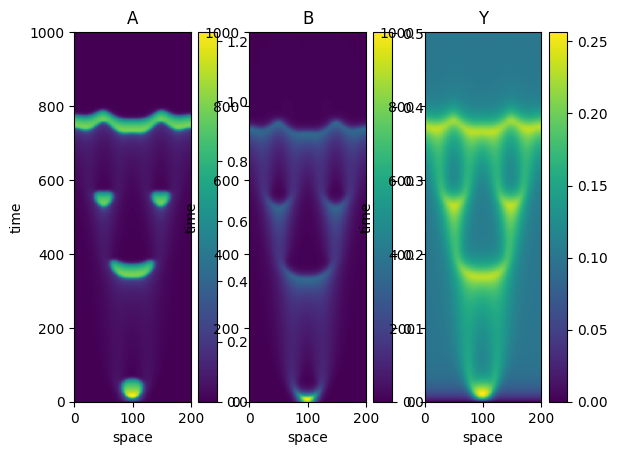

In [274]:
plt.figure()
plt.subplot(131)
plt.pcolor(solution.ys.A.values)
plt.colorbar()
plt.xlabel('space')
plt.ylabel('time')
plt.title('A')

#plt.figure()
plt.subplot(132)
plt.pcolor(solution.ys.B.values)
plt.colorbar()
plt.xlabel('space')
plt.ylabel('time')
plt.title('B')

#plt.figure()
plt.subplot(133)
plt.pcolor(solution.ys.Y.values)
plt.colorbar()
plt.xlabel('space')
plt.ylabel('time')
plt.title('Y')

In [271]:
plt.savefig(r'/media/brandon/Data1/Brandon/fly_immune/sfi2/Ymodel_example_1.png')

In [186]:
KDs = np.logspace(-2, -0.5, 5)
B0s = np.logspace(-4, 0, 20)
t_max = 100
L = 100.0
n = 200
shape = (n,)
lb = [0]
h = L / (n - 1)
kwargs = dict(dt0=1e-4, max_steps=100000000, atol=1e-3, rtol=1e-3)

final_integrated_A = np.zeros((len(KDs), len(B0s)), dtype=int)
for i, KD in enumerate(KDs):
    print(f"{KD=:.2f}")
    with Pool(processes=10) as pool:
        func = partial(response, KD=KD, t_max=t_max)
        res = pool.map(func, B0s)
        final_integrated_A[i] = np.array(res)
        # for j, B0 in enumerate(B0s):
        #     final_integrated_A[i, j] = response(B0, θ, t_max)


KD=0.01


/home/brandon/anaconda3/envs/immunowave/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


NameError: name 'response' is not defined

In [61]:
%matplotlib qt

In [62]:
mpl.rc('axes', linewidth=4)

<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1571882/4206344869.py:4: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(KDs, (9 * np.pi / 16) *KDs ** (3/2), 'k--', linewidth=4, label='$(9\pi/16)θ^{3/2}$')


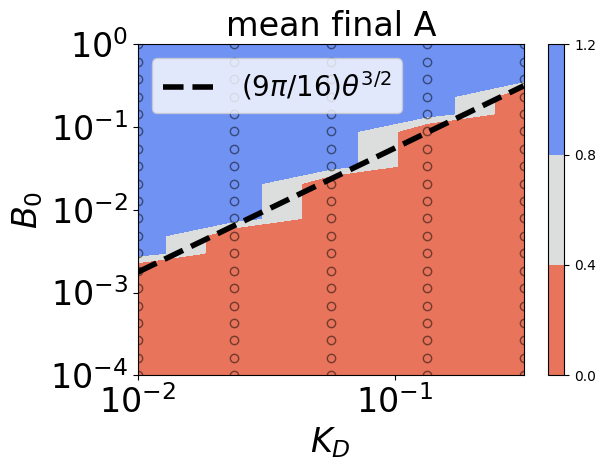

In [57]:
plt.figure()
ax = plt.contourf(KDs, B0s, final_integrated_A.T / L, cmap="coolwarm_r", levels=2)
plt.colorbar()
plt.plot(KDs, (9 * np.pi / 16) *KDs ** (3/2), 'k--', linewidth=4, label='$(9\pi/16)θ^{3/2}$')
for B0 in B0s:
    plt.plot(KDs, B0 * np.ones_like(KDs), 'ko', markerfacecolor='none', linewidth=2, alpha=0.5, label='_none_')
plt.legend(fontsize=20)
plt.xlim(np.min(KDs), np.max(KDs))
plt.ylim(np.min(B0s), np.max(B0s))
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$B_0$", fontsize=24)
plt.xlabel(r"$K_D$", fontsize=24)
#plt.xlim([2e-3, 10 ** (-0.5)])
#plt.ylim([1e-5, 1e1])
plt.minorticks_off()
ax = plt.gca()
fontproperties = {'family':'sans-serif','sans-serif':['Arial'],'weight' : 'bold', 'size' : 24}
ax.xaxis.set_tick_params(labelsize=20)
ax.yaxis.set_tick_params(labelsize=20)
for tick in ax.xaxis.get_major_ticks():
    tick.label1.set_fontsize(24)
for tick in ax.yaxis.get_major_ticks():
    tick.label1.set_fontsize(24)
plt.title('mean final A', fontsize=24)
plt.tight_layout()
plt.show()

In [58]:
def find_B0(final_mean_A, B0s):
    this_id = np.where(np.diff(final_mean_A) == np.max(np.diff(final_mean_A)))[0][0]
    B0c = 0.5 * (B0s[this_id] + B0s[this_id + 1])
    uncertainty = 0.5 * (B0s[this_id+1] - B0s[this_id])
    return B0c, uncertainty

In [67]:
B0c = np.zeros_like(KDs)
B0c_uncertainties = np.zeros_like(KDs)
for i in range(len(B0c)):
    these_As = final_integrated_A[i]
    B0c[i], B0c_uncertainties[i] = find_B0(these_As, B0s)

In [68]:
plt.figure()
#plt.plot(θs, B0c, 'go', markersize=24, markerfacecolor='none', markeredgewidth=4)
plt.errorbar(KDs, B0c, B0c_uncertainties, marker='o', markersize=18, markerfacecolor='none', 
             markeredgewidth=4, linestyle='none', markeredgecolor='g', elinewidth=4, capsize=6, ecolor='g', label='numerical')
plt.plot(KDs, (9 * np.pi / 16) *KDs ** (3/2), 'k--', linewidth=4, label='$(9\pi/16)K^{3/2}_D$')
plt.legend(fontsize=20)
#plt.xlim(np.min(θs), np.max(θs))
#plt.ylim(np.min(B0s), np.max(B0s))
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$B_{0,c}$", fontsize=24)
plt.xlabel(r"$K_D$", fontsize=24)
#plt.xlim([2e-3, 10 ** (-0.5)])
#plt.ylim([1e-5, 1e1])
plt.minorticks_off()
ax = plt.gca()
fontproperties = {'family':'sans-serif','sans-serif':['Arial'],'weight' : 'bold', 'size' : 24}
ax.xaxis.set_tick_params(labelsize=20)
ax.yaxis.set_tick_params(labelsize=20)
for tick in ax.xaxis.get_major_ticks():
    tick.label1.set_fontsize(24)
for tick in ax.yaxis.get_major_ticks():
    tick.label1.set_fontsize(24)
plt.tight_layout()
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1571882/885773749.py:5: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(KDs, (9 * np.pi / 16) *KDs ** (3/2), 'k--', linewidth=4, label='$(9\pi/16)K^{3/2}_D$')


In [57]:
final_integrated_A

array([[ 0,  0,  0,  0, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
        20, 20, 20, 20],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 20, 20, 20, 20, 20, 20, 20, 20,
        20, 20, 20, 20],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 20, 20, 20, 20, 20,
        20, 20, 20, 21],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 20, 20,
        20, 20, 20, 21],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0, 20, 20, 21]])

In [21]:
plt.savefig(r'/media/brandon/Data1/Brandon/fly_immune/sfi2/B0c_vs_theta_example1_finer_B0_grid_L100_scale5.pdf')

In [19]:
import pickle

In [20]:
with open(r'/media/brandon/Data1/Brandon/fly_immune/sfi2/2024_03_15_grid_search_L100_scale5.pkl', 'wb') as f:
    out_dict = {}
    out_dict['θs'] = θs
    out_dict['B0s'] = B0s
    out_dict['t_max'] = t_max
    out_dict['L'] = L
    out_dict['n'] = n
    out_dict['lb'] = lb
    out_dict['shape'] = shape
    out_dict['h'] = h
    out_dict['kwargs'] = kwargs
    out_dict['η'] = 1.0
    out_dict['ξ'] = 0.0
    out_dict['λ'] = 0.0
    out_dict['μ'] = 0.0
    out_dict['final_integrated_A'] = final_integrated_A
    out_dict['initial_B_shape'] = 'gaussian'
    out_dict['initial_B_width'] = 5
    
    pickle.dump(out_dict, f)

In [27]:
with open(r'/media/brandon/Data1/Brandon/fly_immune/sfi2/2024_03_15_grid_search_L100_scale5.pkl', 'rb') as f:
    out_dict = pickle.load(f)

In [21]:
out_dict

{'θs': array([0.01      , 0.02371374, 0.05623413, 0.13335214, 0.31622777]),
 'B0s': array([1.00000000e-04, 1.62377674e-04, 2.63665090e-04, 4.28133240e-04,
        6.95192796e-04, 1.12883789e-03, 1.83298071e-03, 2.97635144e-03,
        4.83293024e-03, 7.84759970e-03, 1.27427499e-02, 2.06913808e-02,
        3.35981829e-02, 5.45559478e-02, 8.85866790e-02, 1.43844989e-01,
        2.33572147e-01, 3.79269019e-01, 6.15848211e-01, 1.00000000e+00]),
 't_max': 1000,
 'L': 20.0,
 'n': 1200,
 'lb': [0],
 'shape': (1200,),
 'h': 0.016680567139282735,
 'kwargs': {'dt0': 0.0001,
  'max_steps': 100000000,
  'atol': 0.001,
  'rtol': 0.001},
 'η': 1.0,
 'ξ': 0.0,
 'λ': 0.0,
 'μ': 0.0,
 'final_integrated_A': array([[ 0,  0,  0,  0, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
         20, 20, 20, 20],
        [ 0,  0,  0,  0,  0,  0,  0, 20, 20, 20, 20, 20, 20, 20, 20, 20,
         20, 20, 20, 20],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 20, 20, 20, 20, 20,
         20, 20, 20, 20],
     

In [71]:
from scipy.stats import linregress

In [72]:
res = linregress(np.log10(KDs), np.log10(B0c))

In [73]:
res.slope

2.077192982456141

In [74]:
res.stderr

0.05614035087718824

In [69]:
x = np.log10(KDs)
y = np.log10(B0c)

slope = np.sum(x*y) / np.sum(x ** 2)
print(slope)

1.8925944422509093


In [45]:
plt.figure()
plt.plot(x, y, 'ko')